In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
# Tratamiento de Datos
import pandas as pd
import numpy as np
from IPython.display import display

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Para que se muestren todas las columnas al inspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

In [3]:
from framework import sp_carga_exploracion as sc
from framework import sp_limpieza_transformacion as sl
from framework import sp_eda as se
# from framework import sp_abtest as sb
# from framework import sp_modelado as sm
# from framework import sp_clustering as cl
# from framework import sp_series_temporales as st
# from framework import sp_imputacion_avanzada as sa


**---- Notebooks ----**<br>
00_consultas_referencia.ipynb<br>
01_carga_exploracion.ipynb<br>
02_limpieza_transformacion.ipynb<br>
03_eda.ipynb<br>
04_abtest.ipynb<br>
05_modelado.ipynb<br>
06_clustering.ipynb<br>
07_series_temporales.ipynb<br>
08_dashboard.ipynb<br>

**USOS DE DF** 
- UNIVARIABLE --> usar grupos temáticos
- BIVARIABLE CON TV --> usar df_origen
- CORRELACIONES --> usar df_origen    
- MODELADO --> usar df_origen

-- CORRELACIONES <br>
**Numéricas**<br>
groupby('objetivo').mean()<br>
**Categóricas**<br>
crosstab(col, objetivo, normalize='index')

In [7]:
ruta = (r"../data/raw/dataset_estudiantes.csv")
df = sc.leer_csv(ruta)

CSV CARGADO
Archivo: ../data/raw/dataset_estudiantes.csv
Filas:   1000
Columnas: 11


In [7]:
df_c = df.copy()

#### EXPLORACION INICAL

In [8]:
sc.exploracion_inicial(df_c)

5 FILAS ALEATORIAS


,141,662,681
horas_estudio_semanal,2.874947,8.686571,22.877417
nota_anterior,85.862275,95.42384,100.0
tasa_asistencia,92.840767,100.0,100.0
horas_sueno,8.043862,6.166807,6.744723
edad,29,22,18
nivel_dificultad,Fácil,Difícil,Difícil
tiene_tutor,No,No,Sí
horario_estudio_preferido,Tarde,Tarde,Tarde
estilo_aprendizaje,Visual,Visual,Visual
nota_final,56.0,79.1,85.7


DIMENSIONES
El número de filas es: 1000 filas 
El número de columnas es: 11 columnas
INFORMACION BASICA
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   horas_estudio_semanal      1000 non-null   float64
 1   nota_anterior              1000 non-null   float64
 2   tasa_asistencia            1000 non-null   float64
 3   horas_sueno                850 non-null    float64
 4   edad                       1000 non-null   int64  
 5   nivel_dificultad           1000 non-null   str    
 6   tiene_tutor                1000 non-null   str    
 7   horario_estudio_preferido  900 non-null    str    
 8   estilo_aprendizaje         950 non-null    str    
 9   nota_final                 1000 non-null   float64
 10  aprobado                   1000 non-null   int64  
dtypes: float64(5), int64(2), str(4)
memory usage: 108.0 KB
None
COLUMNAS

,count,unique,top,freq
nivel_dificultad,1000,3,Medio,504
tiene_tutor,1000,2,No,597
horario_estudio_preferido,900,3,Noche,344
estilo_aprendizaje,950,4,Visual,363


ESTADISTICOS NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,1000.0,10.072366,4.852218,1.0,6.627548,10.000000,13.372452,25.0
nota_anterior,1000.0,69.885456,14.687697,30.0,59.882644,70.000000,80.117356,100.0
tasa_asistencia,1000.0,73.992079,18.195948,20.0,61.510192,75.000000,88.489808,100.0
horas_sueno,850.0,7.007670,1.444790,4.0,5.995341,7.020701,8.018834,10.0
edad,1000.0,23.532000,3.476933,18.0,21.000000,24.000000,27.000000,29.0
nota_final,1000.0,71.441400,9.562078,30.0,64.775000,71.400000,77.900000,100.0
aprobado,1000.0,0.898000,0.302800,0.0,1.000000,1.000000,1.000000,1.0


#### CALIDAD DATASET

In [9]:
sl.reporte_calidad(df_c)

,tipo,ejemplos
horas_estudio_semanal,float64,"[8.957475998038344, 11.042524001961656, 4.510776081457513]"
nota_anterior,float64,"[48.83060095398218, 80.82570664326124, 90.38369427718838]"
tasa_asistencia,float64,"[86.64018172631499, 83.44965544904211, 74.62360717097394]"
horas_sueno,float64,"[6.675694179152657, 4.616843562140823, 7.755246085587813]"
edad,int64,"[25, 18, 23]"
nivel_dificultad,str,"[Fácil, Difícil, Medio]"
tiene_tutor,str,"[Sí, No]"
horario_estudio_preferido,str,"[Tarde, Mañana, Noche]"
estilo_aprendizaje,str,"[Lectura/Escritura, Visual, Auditivo]"
nota_final,float64,"[84.4, 72.0, 80.0]"


#### EDA PRELIMINAR - CALIDAD DEL DATASET

In [4]:
df_e = sc.leer_csv('../data/processed/02_datos_limpios.csv')

CSV CARGADO
Archivo: ../data/processed/02_datos_limpios.csv
Filas:   1000
Columnas: 12


VARIABLES NUMERICAS:

 Index(['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia', 'horas_sueno', 'edad', 'nota_final', 'aprobado', 'tiene_tutor_ml'], dtype='str')

VARIABLES CATEGORICAS:

 Index(['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido', 'estilo_aprendizaje'], dtype='str')

VARIABLES DATETIME(FECHA):

 Index([], dtype='str')

========== ESTADÍSTICAS BÁSICAS ==========

VARIABLES NUMERICAS:
                        count   mean    std   min    25%    50%    75%    max
horas_estudio_semanal  1000.0  10.07   4.85   1.0   6.63  10.00  13.37   25.0
nota_anterior          1000.0  69.89  14.69  30.0  59.88  70.00  80.12  100.0
tasa_asistencia        1000.0  73.99  18.20  20.0  61.51  75.00  88.49  100.0
horas_sueno            1000.0   7.01   1.33   4.0   6.19   7.01   7.82   10.0
edad                   1000.0  23.53   3.48  18.0  21.00  24.00  27.00   29.0
nota_final             1000.0  71.44   9.56  30.0  64.78  71.40  77.90  100.0
aprobado               1000.0 

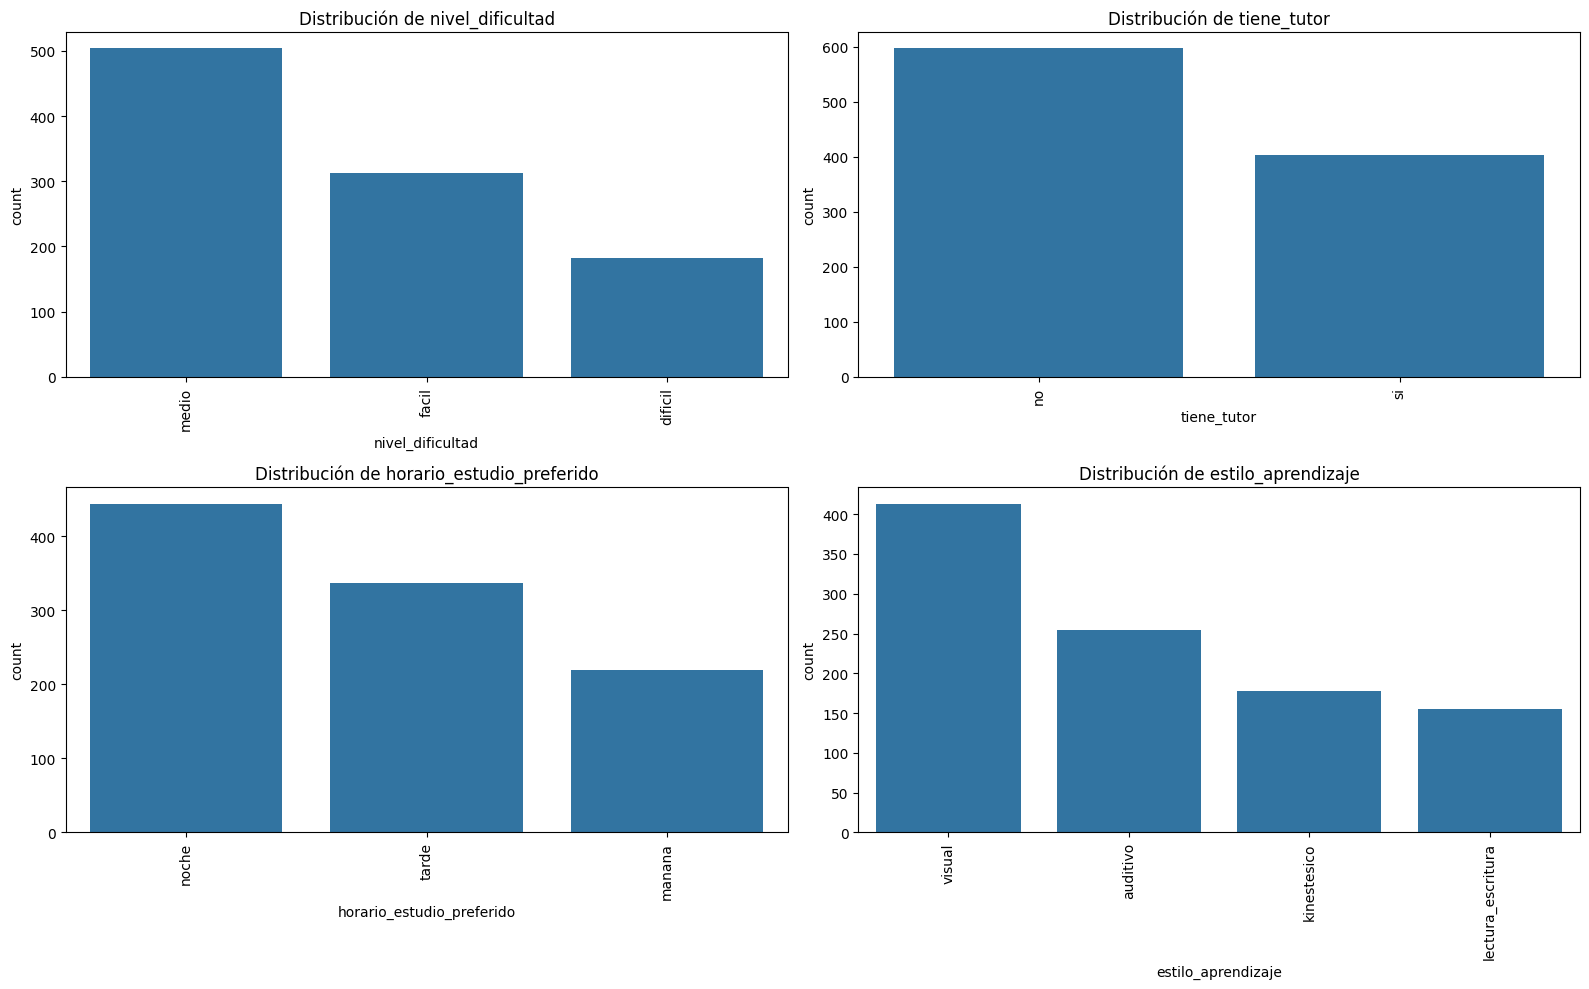


============== HISTOGRAMAS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS):


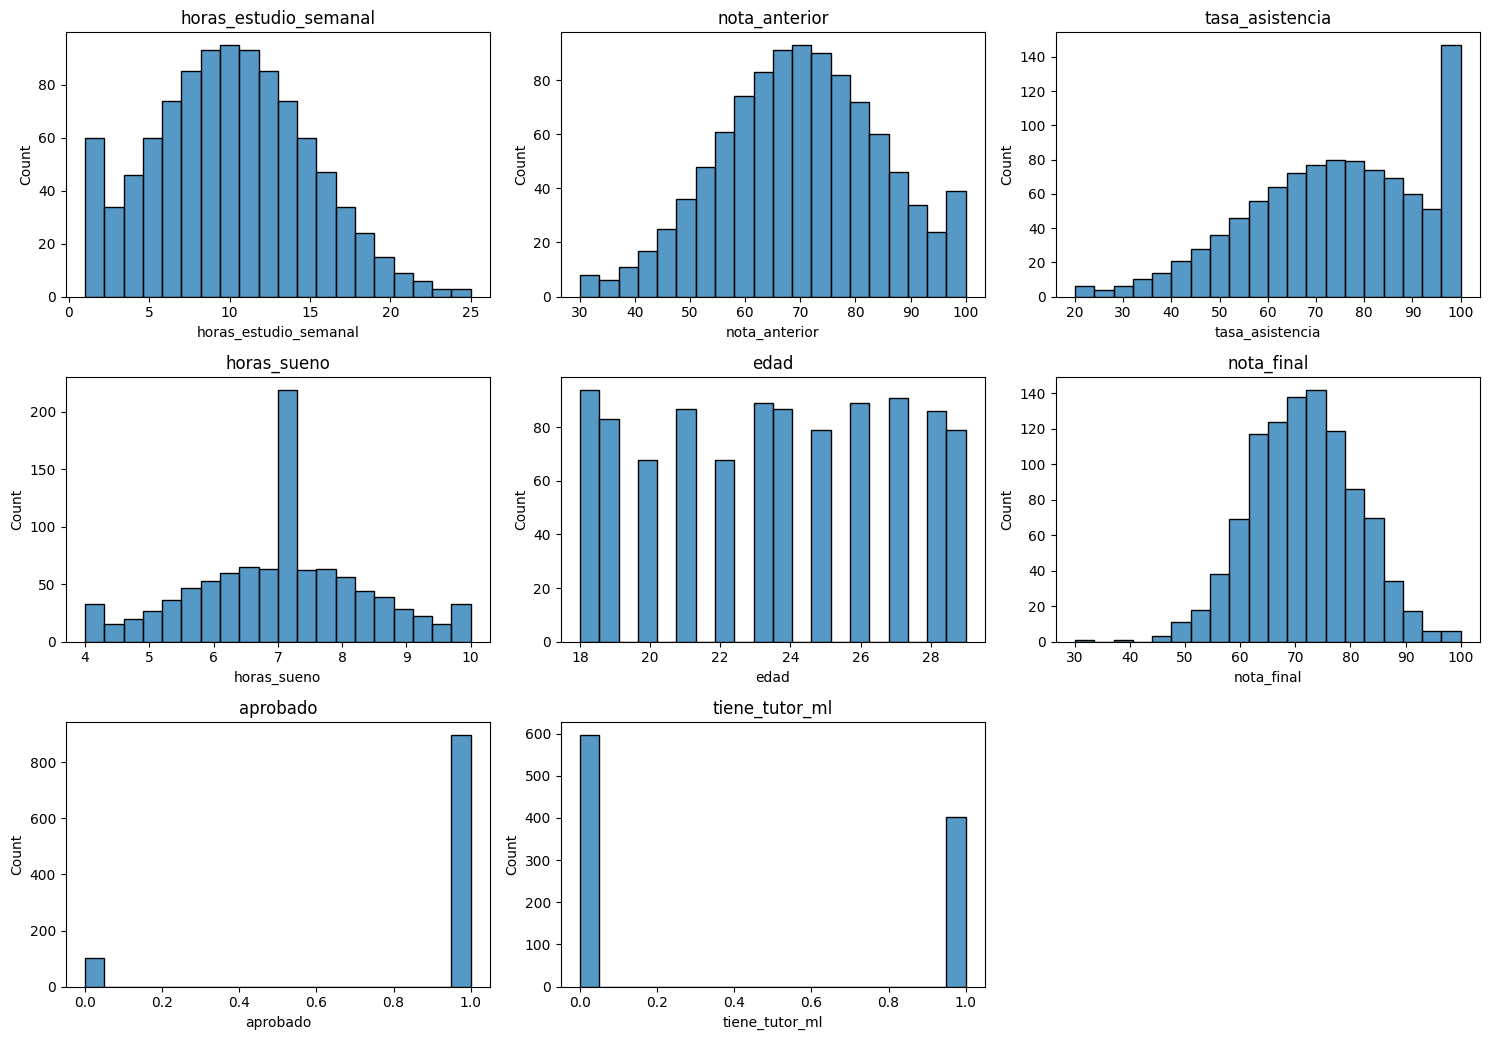


============== BOXPLOTS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS - OUTLIERS)


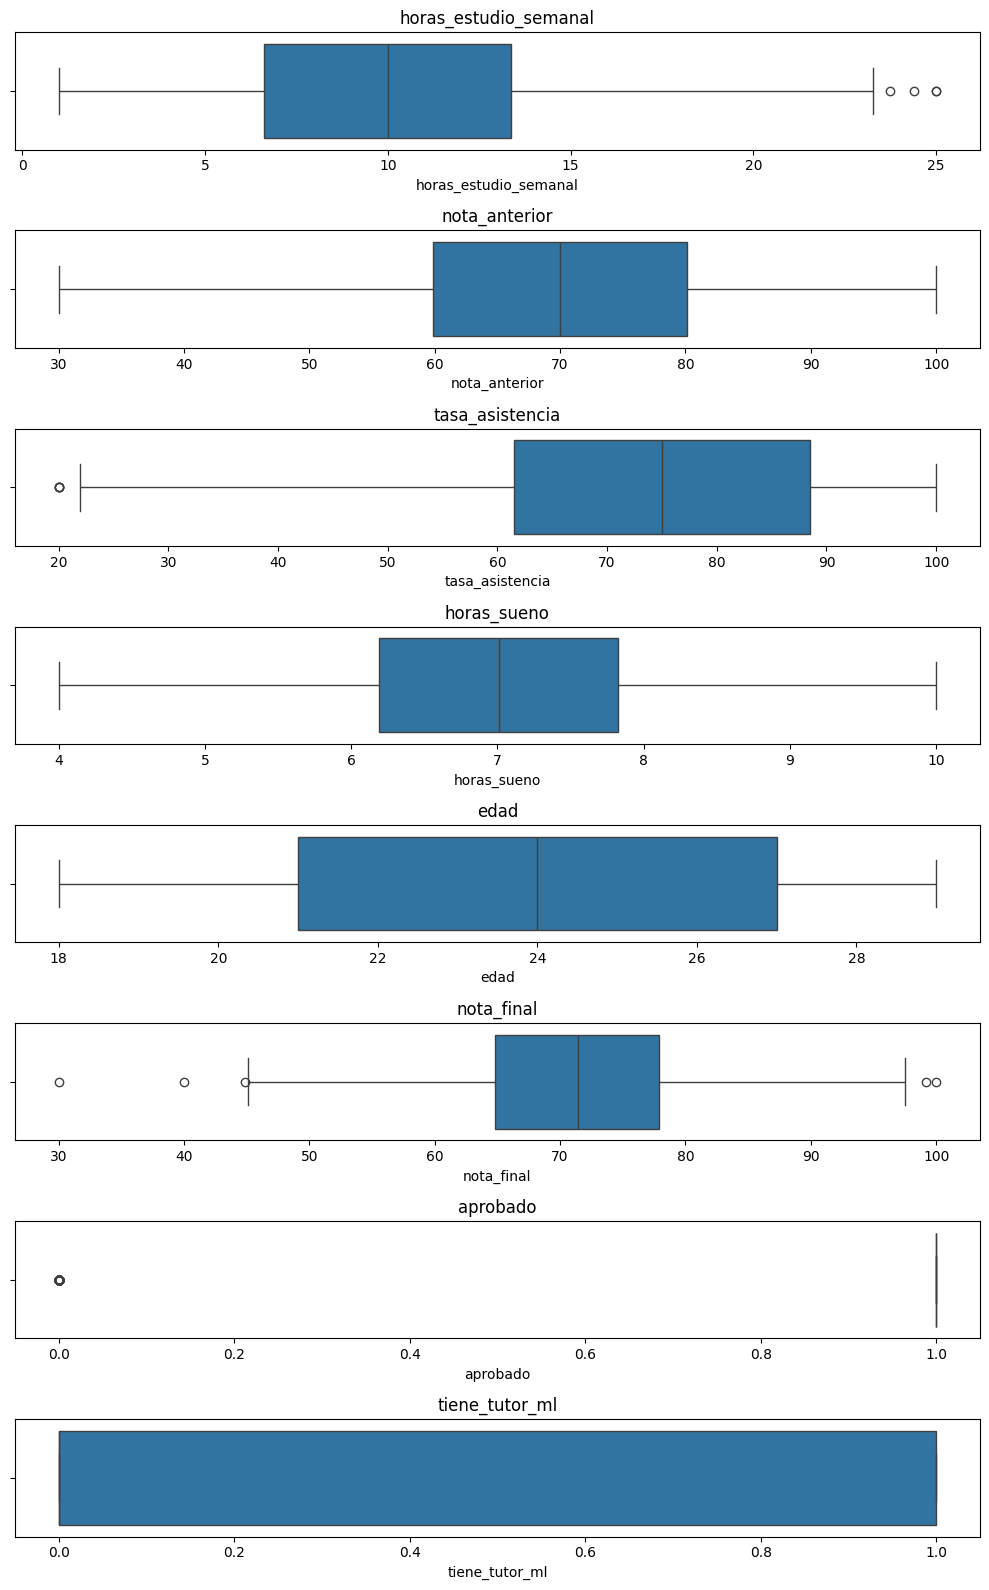

In [6]:
se.eda_consultas(df_e, cols_excluir=None)